In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets,transforms
from torch.utils.data import DataLoader,random_split,TensorDataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

In [3]:
class LSTMCell(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.Wf=nn.Linear(input_size+hidden_size,hidden_size)
        self.Wi=nn.Linear(input_size+hidden_size,hidden_size)
        self.Wg=nn.Linear(input_size+hidden_size,hidden_size)
        self.Wo=nn.Linear(input_size+hidden_size,hidden_size)

    def forward(self,x,h_prev,c_prev):
        combined=torch.cat([h_prev,x],dim=1)
        f=torch.sigmoid(self.Wf(combined))
        i=torch.sigmoid(self.Wi(combined))
        g=torch.tanh(self.Wg(combined))
        o=torch.sigmoid(self.Wo(combined))
        c_new=f*c_prev+i*g
        h_new=o*torch.tanh(c_new)
        return h_new,c_new

In [4]:
class LSTMStacked(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.lstm1=LSTMCell(input_size,hidden_size)
        self.lstm2=LSTMCell(hidden_size,hidden_size)
        self.hidden_size=hidden_size

    def forward(self,x):
        batch_size=x.size(0)
        seq_len=x.size(1)
        
        h1=torch.zeros(batch_size,self.hidden_size)
        c1=torch.zeros(batch_size,self.hidden_size)
        h2=torch.zeros(batch_size,self.hidden_size)
        c2=torch.zeros(batch_size,self.hidden_size)

        for t in range(seq_len):
            x_t=x[:,t,:]

            h1,c1=self.lstm1(x_t,h1,c1)
            h2,c2=self.lstm2(h1,h2,c2)

        return h2

In [5]:
class LSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.lstm=LSTMStacked(input_size,hidden_size)
        self.fc=nn.Linear(hidden_size,12)

    def forward(self,x):
        out=self.lstm(x)
        out=self.fc(out)
        return out

model=LSTMModel(input_size=14,hidden_size=64)

In [6]:
df=pd.read_csv('/kaggle/input/datasets/mnassrib/jena-climate/jena_climate_2009_2016.csv')
df['Date Time']=pd.to_datetime(df['Date Time'],dayfirst=True)
df=df.sort_values(['Date Time'])
features = [
    "p (mbar)",
    "T (degC)",
    "Tpot (K)",
    "Tdew (degC)",
    "rh (%)",
    "VPmax (mbar)",
    "VPact (mbar)",
    "VPdef (mbar)",
    "sh (g/kg)",
    "H2OC (mmol/mol)",
    "rho (g/m**3)",
    "wv (m/s)",
    "max. wv (m/s)",
    "wd (deg)"
]

data=df[features]
n=len(data)
train_end=int(n*0.7)
val_end=int(n*0.85)

train_data = data[:train_end]
val_data = data[train_end:val_end]
test_data = data[val_end:]

print(
    len(train_data),
    len(val_data),
    len(test_data)
)

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

294385 63083 63083


In [7]:
def create_sequences(data, seq_len=72, future=12):
    X = []
    y = []
    for i in range(len(data)-seq_len-future):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len : i+seq_len+future, 1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled)
X_val, y_val = create_sequences(val_scaled)
X_test, y_test = create_sequences(test_scaled)

print("X train:",X_train.shape)
print("y train:",y_train.shape)

X train: (294301, 72, 14)
y train: (294301, 12)


In [8]:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [9]:
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters(),lr=0.001,weight_decay=1e-5)
scheduler=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=10)
num_epochs=10
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    model.train()
    batchloss=0
    for X_batch,y_batch in train_loader:
        
        optimizer.zero_grad()
        
        y_batch_pred=model(X_batch)
        
        l=criterion(y_batch_pred,y_batch)
        
        l.backward()
        
        optimizer.step()
        
        batchloss+=l.item()
        
    
    model.eval()
    val_loss=0

    with torch.no_grad():
        for X_batch,y_batch in val_loader:
            
            y_batch_pred=model(X_batch)
 
            val_loss+=criterion(y_batch_pred,y_batch).item()


    scheduler.step()

    batchloss/=len(train_loader)
    train_losses.append(batchloss)
    val_losses.append((val_loss/len(val_loader))) 
    print(f'Epoch {epoch+1}/{num_epochs} Train Loss: {batchloss:.4f} Val Loss: {val_loss/len(val_loader):.4f}')

Epoch 1/10 Train Loss: 0.0158 Val Loss: 0.0110
Epoch 2/10 Train Loss: 0.0090 Val Loss: 0.0095
Epoch 3/10 Train Loss: 0.0085 Val Loss: 0.0089
Epoch 4/10 Train Loss: 0.0082 Val Loss: 0.0090
Epoch 5/10 Train Loss: 0.0079 Val Loss: 0.0089
Epoch 6/10 Train Loss: 0.0076 Val Loss: 0.0090
Epoch 7/10 Train Loss: 0.0074 Val Loss: 0.0089
Epoch 8/10 Train Loss: 0.0071 Val Loss: 0.0087
Epoch 9/10 Train Loss: 0.0069 Val Loss: 0.0086
Epoch 10/10 Train Loss: 0.0068 Val Loss: 0.0085


In [10]:
model.eval()
test_loss = 0
preds = []
actuals = []

with torch.no_grad():
    for X_batch,y_batch in test_loader:
        
        y_pred = model(X_batch)
        loss = criterion(y_pred,y_batch)
        test_loss += loss.item()

        preds.extend(y_pred.numpy())
        actuals.extend(y_batch.numpy())

test_loss /= len(test_loader)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.0071


In [11]:
preds = np.array(preds)
actuals = np.array(actuals)

def inverse_transform_temp(values, scaler, temp_col_idx=1, n_features=14):
    dummy = np.zeros((values.shape[0]*values.shape[1], n_features))
    dummy[:, temp_col_idx] = values.flatten()
    inv = scaler.inverse_transform(dummy)[:, temp_col_idx]
    return inv.reshape(values.shape)

preds_celsius = inverse_transform_temp(preds, scaler)
actuals_celsius = inverse_transform_temp(actuals, scaler)

mae = np.mean(np.abs(preds_celsius - actuals_celsius))
rmse = np.sqrt(np.mean((preds_celsius - actuals_celsius)**2))
print(f"MAE: {mae:.3f} °C")
print(f"RMSE: {rmse:.3f} °C")

MAE: 0.476 °C
RMSE: 0.727 °C


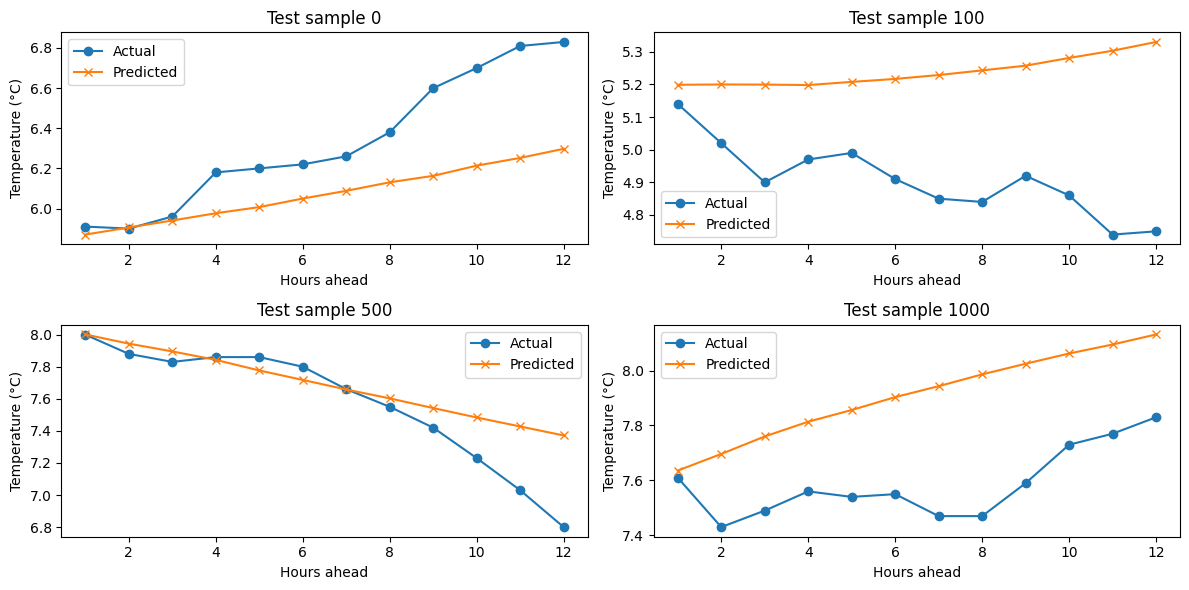

In [12]:
plt.figure(figsize=(12, 6))
sample_indices = [0, 100, 500, 1000]  # pick a few random test windows

for idx, i in enumerate(sample_indices):
    plt.subplot(2, 2, idx+1)
    plt.plot(range(1, 13), actuals_celsius[i], label='Actual', marker='o')
    plt.plot(range(1, 13), preds_celsius[i], label='Predicted', marker='x')
    plt.xlabel('Hours ahead')
    plt.ylabel('Temperature (°C)')
    plt.title(f'Test sample {i}')
    plt.legend()

plt.tight_layout()
plt.savefig('lstm_predictions.png')
plt.show()

              precision    recall  f1-score   support

        down       0.74      0.65      0.69     22719
      stable       0.53      0.64      0.58     21878
          up       0.71      0.64      0.68     18402

    accuracy                           0.64     62999
   macro avg       0.66      0.64      0.65     62999
weighted avg       0.66      0.64      0.65     62999



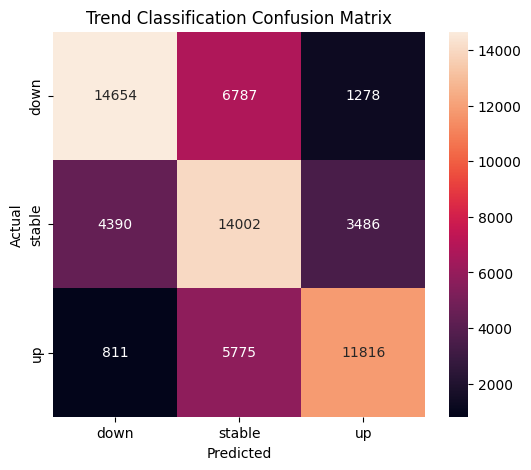

In [13]:
def to_trend_classes(values, threshold=0.5):
    diff = values[:, -1] - values[:, 0]   # change from hour 1 to hour 12
    classes = np.where(diff > threshold, 2, np.where(diff < -threshold, 0, 1))  # 0=down,1=stable,2=up
    return classes

pred_classes = to_trend_classes(preds_celsius)
actual_classes = to_trend_classes(actuals_celsius)

print(classification_report(actual_classes, pred_classes, target_names=['down','stable','up']))

cm = confusion_matrix(actual_classes, pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=['down','stable','up'], yticklabels=['down','stable','up'])
plt.title('Trend Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('lstm_confusion_matrix.png')
plt.show()

In [14]:
torch.save(model.state_dict(), 'lstm_jena.pth')

---------

## REPORT
**Role of each gate**

The forget gate (f = sigmoid(W_f · [h, x])) decides what fraction of the previous cell state to retain — values near 0 erase information, near 1 preserve it. The input gate (i = sigmoid(W_i · [h, x])) controls how much new information to write, working together with the candidate cell state (g = tanh(W_g · [h, x])) which represents the new content to potentially add. The output gate (o = sigmoid(W_o · [h, x])) controls what portion of the updated cell state to expose as the hidden state (h = o * tanh(C)).

**How information is retained or forgotten**

The cell state C = f * C_prev + i * g is the long-term memory of the network. The forget gate can zero out irrelevant past context (e.g. weather patterns from days ago that are no longer predictive), while the input gate writes in new relevant information (e.g. a sudden pressure drop). This selective read/write mechanism is what makes LSTMs effective for time series — they can maintain relevant context across long sequences without gradients vanishing through time.

**Training stability**

Initial training without regularization showed clear overfitting — val loss bottomed out around epoch 5 then increased steadily while train loss kept decreasing. Adding weight_decay=1e-5 to Adam resolved this, producing consistently decreasing val loss across 10 epochs. Final MAE of 0.48°C and RMSE of 0.73°C on the test set indicates good generalization.

**Sequence length considerations**

72 hours of input provides sufficient context for 12-hour ahead forecasting — it captures roughly 3 daily temperature cycles, giving the model enough history to identify diurnal patterns. Shorter windows (e.g. 24h) would lose this cyclical context; longer windows (e.g. 168h/1 week) may introduce irrelevant older data that dilutes the recent signal.

**Forecasting challenges**

The prediction plots reveal the model produces smoother trajectories than the actual temperature curves — it captures overall trend direction well but underestimates short-term hour-to-hour volatility within the 12-hour window. This is a known limitation of fixed-horizon regression heads: predicting all 12 steps from a single final hidden state forces the model to hedge rather than commit to sharp fluctuations. Autoregressive decoding (predicting step by step, feeding each prediction back as input) would likely capture this volatility better at the cost of error accumulation.

----

## Architecture Choices

**Hand-rolled LSTMCell:** Implemented all 4 gate equations explicitly using nn.Linear 
layers rather than nn.LSTM, fulfilling the requirement and making the mechanics 
transparent and inspectable.

**2 Stacked Layers, Hidden Dim 64:** Two layers allow the model to learn temporal 
abstractions at different timescales. Hidden dim 64 chosen as a balance between 
capacity and overfitting risk — 128 overfit more severely in initial runs.

**Multi-step output (12 values):** Final linear layer outputs 12 values simultaneously 
rather than autoregressively, avoiding error accumulation across steps at the cost 
of some fine-grained volatility in predictions.

**weight_decay=1e-5:** Light L2 regularization on Adam prevented the val loss divergence 
seen in early runs without significantly slowing convergence.

**StandardScaler on train split only:** Prevents data leakage — val and test sets 
transformed using train statistics only.